### Correlation Plot between Continuous Attributes

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your metadata CSV
df = pd.read_csv('/home/gamorten/Microbiome_Health/metadata/metadata.csv')

# Select continuous variables
continuous_columns = ['BMI', 'Consent Age', 'Delivery_EGA', 'ca_ld_birth_weight']

# Compute the Pearson correlation for continuous variables
correlation_matrix = df[continuous_columns].corr(method='pearson')

# Visualize the correlation matrix with a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='flare')
plt.title('Pearson Correlation Matrix of Continuous Variables')
plt.show()


ERROR: Error in parse(text = input): <text>:1:8: unexpected symbol
1: import pandas
           ^


### Chi-Square for Categorical Attributes

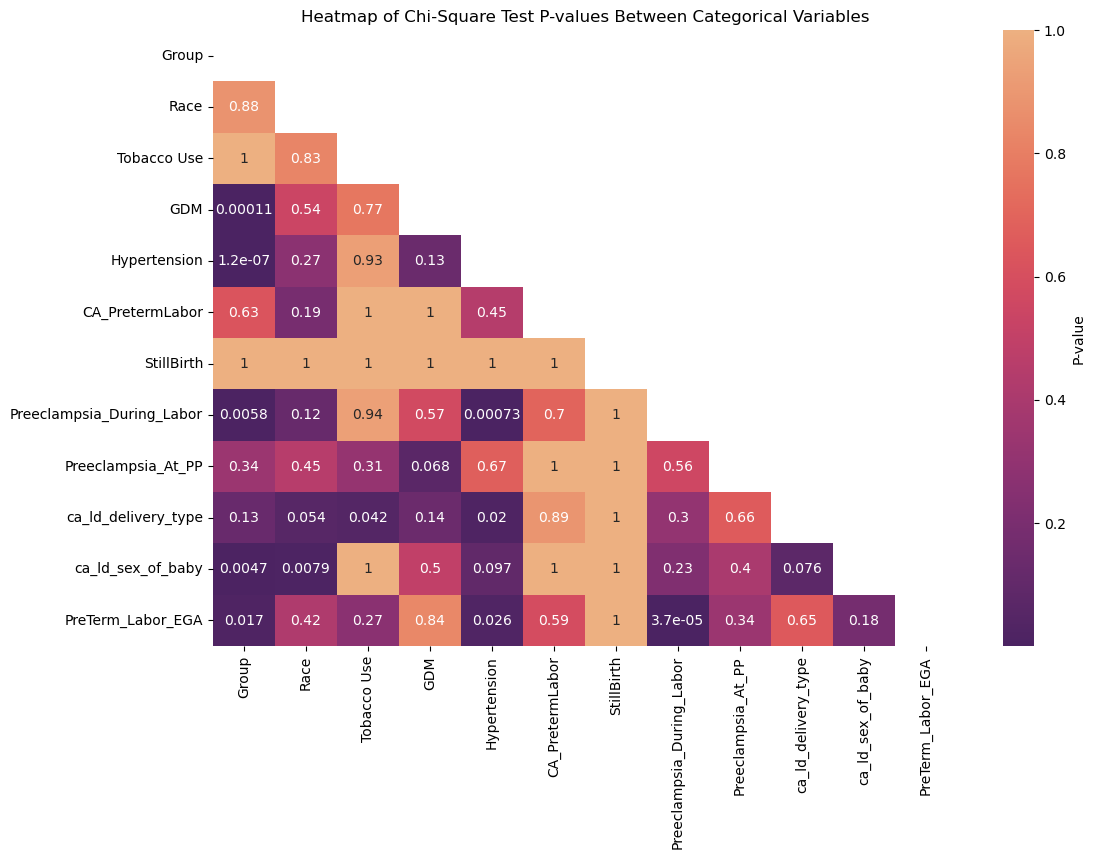

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/home/gamorten/Microbiome_Health/metadata/metadata.csv')

# Define the categorical variables (excluding identifiers and dates)
categorical_columns = ['Group', 'Race', 'Tobacco Use', 'GDM', 'Hypertension',
                       'CA_PretermLabor', 'StillBirth', 'Preeclampsia_During_Labor', 
                       'Preeclampsia_At_PP', 'ca_ld_delivery_type', 'ca_ld_sex_of_baby', 'PreTerm_Labor_EGA']

# Initialize an empty DataFrame to store p-values
p_value_matrix = pd.DataFrame(np.ones((len(categorical_columns), len(categorical_columns))), 
                              columns=categorical_columns, 
                              index=categorical_columns)

# Loop through pairs of categorical variables
for var1 in categorical_columns:
    for var2 in categorical_columns:
        if var1 != var2:
            # Create a contingency table
            contingency_table = pd.crosstab(df[var1], df[var2])
            
            # Perform Chi-Square test
            chi2, p, dof, expected = chi2_contingency(contingency_table)
            
            # Store the p-value in the matrix
            p_value_matrix.loc[var1, var2] = p

# Set up a mask to display only the lower triangle of the heatmap (since it's symmetric)
mask = np.triu(np.ones_like(p_value_matrix, dtype=bool))

# Create a heatmap of the p-value matrix
plt.figure(figsize=(12, 8))
sns.heatmap(p_value_matrix, annot=True, cmap='flare_r', mask=mask, cbar_kws={'label': 'P-value'})
plt.title('Heatmap of Chi-Square Test P-values Between Categorical Variables')
plt.show()


### Stratify Significant Categorical Associations

/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/home/gamorten/bin/miniconda3/envs/microbiome_health/lib/pyt

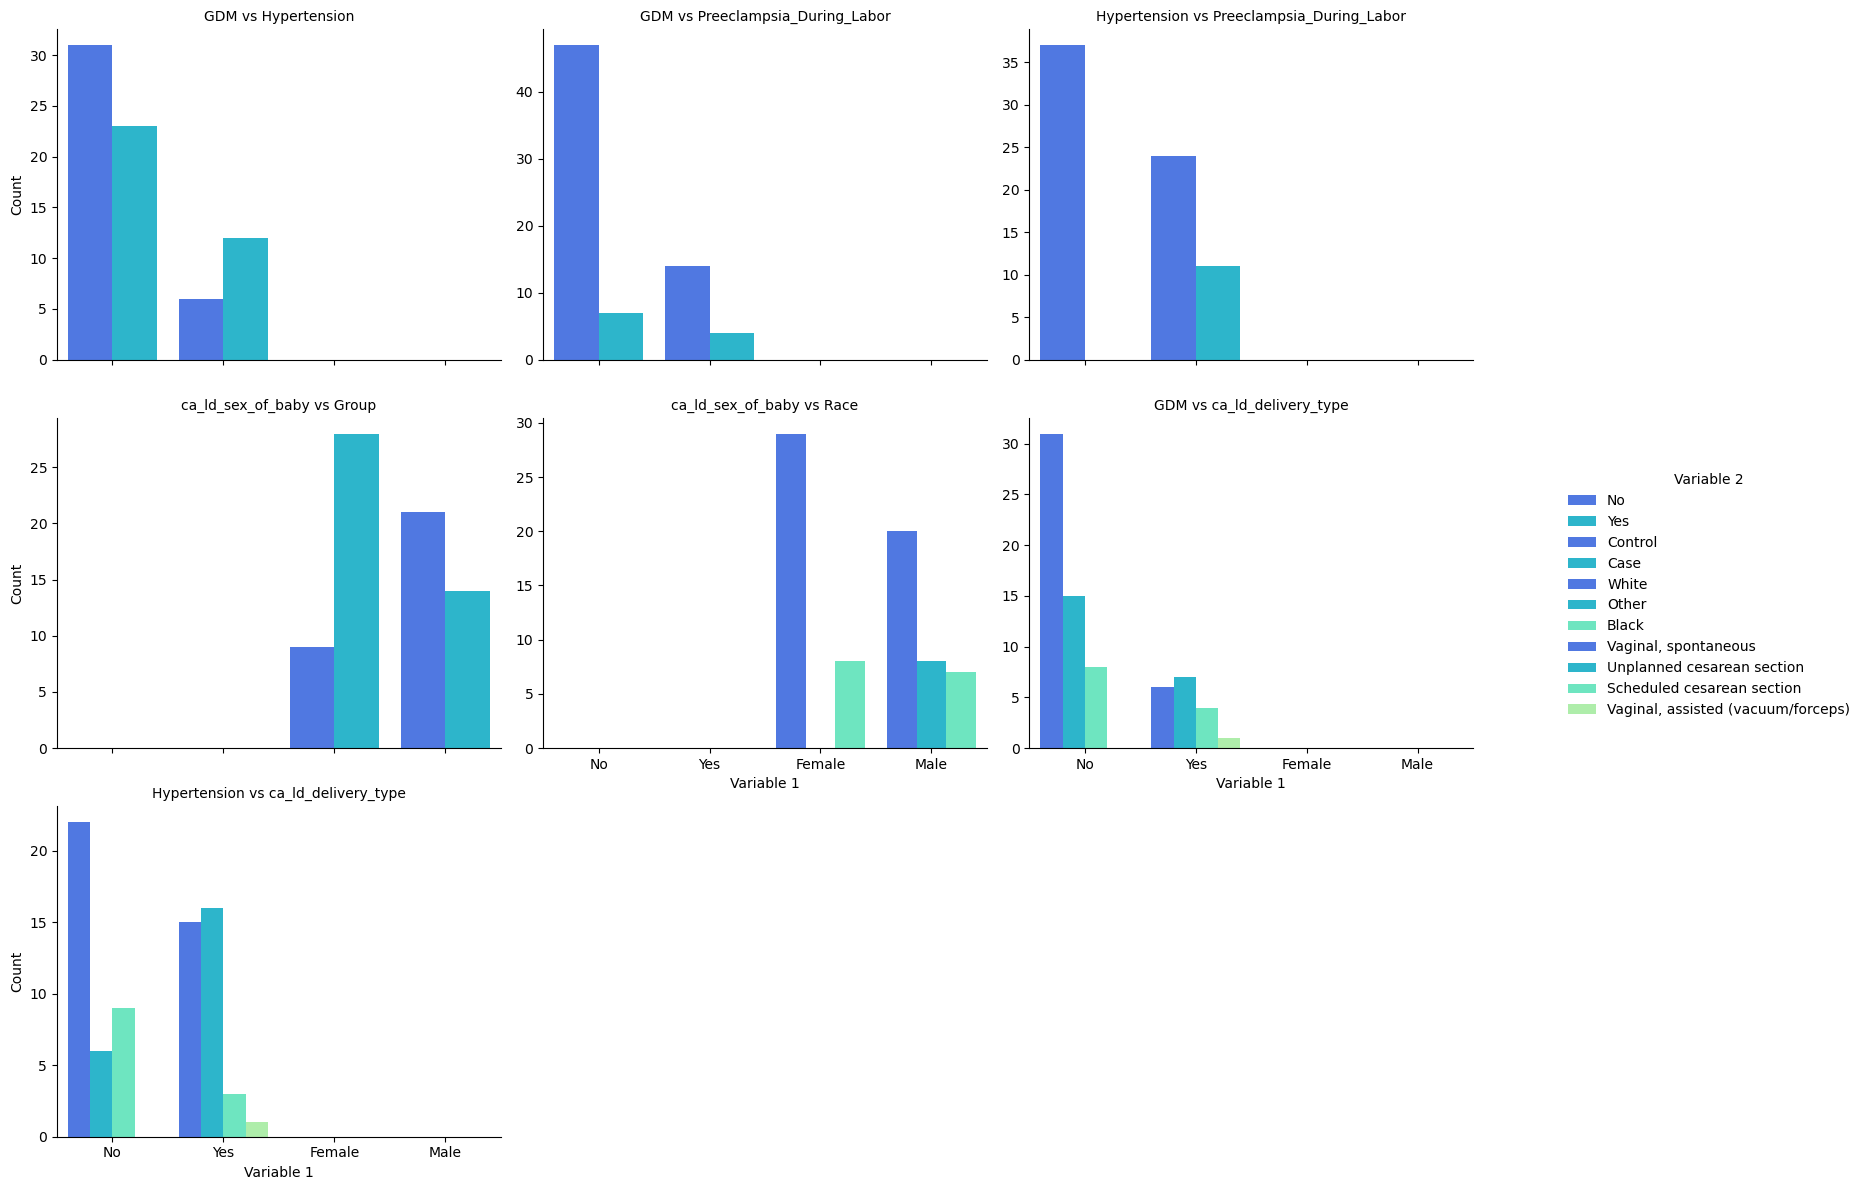

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load your dataset
df = pd.read_csv('/home/gamorten/Microbiome_Health/metadata/metadata.csv')

# Define the significant associations as pairs of categorical variables
associations = [
    ('GDM', 'Hypertension'),
    ('GDM', 'Preeclampsia_During_Labor'),
    ('Hypertension', 'Preeclampsia_During_Labor'),
    ('ca_ld_sex_of_baby', 'Group'),
    ('ca_ld_sex_of_baby', 'Race'),
    ('GDM', 'ca_ld_delivery_type'),
    ('Hypertension', 'ca_ld_delivery_type')
]

# Prepare the data for FacetGrid (melt the categorical associations into long format)
plot_data_list = []

for var1, var2 in associations:
    # Add each pair to the list with the association label
    temp_data = df[[var1, var2]].copy()
    
    # Ensure that both variables are treated as categorical variables
    temp_data[var1] = temp_data[var1].astype('category')
    temp_data[var2] = temp_data[var2].astype('category')
    
    # Add association labels and rename columns for consistency
    temp_data['Association'] = f"{var1} vs {var2}"
    temp_data['Variable1'] = temp_data[var1]
    temp_data['Variable2'] = temp_data[var2]
    plot_data_list.append(temp_data)

# Concatenate the data for all associations
plot_data = pd.concat(plot_data_list)

# Create a FacetGrid for each association
g = sns.FacetGrid(plot_data, col="Association", col_wrap=3, height=4, sharey=False)

# Map a countplot to each subplot, showing the levels of Variable2 for each level of Variable1
g.map_dataframe(sns.countplot, 'Variable1', hue='Variable2', dodge=True, palette=sns.color_palette("rainbow"))

# Adjust plot titles and axis labels
g.set_titles("{col_name}")
g.set_axis_labels("Variable 1", "Count")
g.add_legend(title="Variable 2", bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)

# Display the plot
plt.tight_layout()
plt.show()


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/home/gamorten/Microbiome_Health/metadata/metadata.csv")
df['Hypertension'].value_counts()

Hypertension
No     37
Yes    35
Name: count, dtype: int64